# Notebook 04 — Feature Selection

**Project**: ML-Based QSAR Modeling for Anti-Leishmanial Sulfonamide Derivatives  
**Input**: `data/processed/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`  
**Output**:
- `data/processed/X_train_selected.csv` — Training descriptors after feature selection
- `data/processed/X_test_selected.csv` — Test descriptors (same features, no leakage)
- `data/processed/selected_features.csv` — Names of selected features
- `models/scaler.joblib` — Fitted StandardScaler

**Pipeline** (training set only — applied to test set after):
1. StandardScaler normalization
2. Mutual Information ranking → keep top 75% (MI > 25th percentile)
3. Random Forest importance ranking → keep top 75%
4. Boruta wrapper feature selection (shadow feature comparison)
5. Final features = Boruta ∪ (MI∩RF intersection)

**QC-4**: Zero data leakage — scaler and feature selector fitted on train only.

---

In [1]:
# ============================================================
# CELL 1: Imports and Configuration
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import sys
import joblib
from datetime import datetime

warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

(PROJECT_ROOT / 'models').mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / 'figures').mkdir(parents=True, exist_ok=True)

from boruta import BorutaPy
print(f"Project root : {PROJECT_ROOT}")
print(f"Timestamp    : {datetime.now().strftime('%Y-%m-%d %H:%M')}")


Project root : e:\PhD_Projecttttttttttttt\PhD_QSAR_Leishmania
Timestamp    : 2026-05-17 13:52


In [2]:
# ============================================================
# CELL 2: Load Processed Data
# ============================================================

DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

print("Loading processed data...")
X_train = pd.read_csv(DATA_DIR / 'X_train.csv', index_col=0)
X_test  = pd.read_csv(DATA_DIR / 'X_test.csv',  index_col=0)

# y CSV has columns: pIC50, activity_class  →  extract binary label
y_train_df = pd.read_csv(DATA_DIR / 'y_train.csv', index_col=0)
y_test_df  = pd.read_csv(DATA_DIR / 'y_test.csv',  index_col=0)

y_train = (y_train_df['activity_class'] == 'Active').astype(int)
y_test  = (y_test_df['activity_class']  == 'Active').astype(int)

n_active_train   = int(y_train.sum())
n_inactive_train = len(y_train) - n_active_train
n_active_test    = int(y_test.sum())
n_inactive_test  = len(y_test) - n_active_test

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}  active={n_active_train}  inactive={n_inactive_train}")
print(f"y_test  : {y_test.shape}   active={n_active_test}   inactive={n_inactive_test}")
assert X_train.shape[1] == X_test.shape[1], "Column mismatch between train and test!"
print("\nData loaded successfully.")


Loading processed data...


X_train : (8627, 2111)
X_test  : (4068, 2111)
y_train : (8627,)  active=4650  inactive=3977
y_test  : (4068,)   active=2188   inactive=1880

Data loaded successfully.


In [3]:
# ============================================================
# CELL 3: StandardScaler — fit on TRAIN only
# ============================================================

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

joblib.dump(scaler, PROJECT_ROOT / 'models' / 'scaler.joblib')
print(f"Scaler fitted on {X_train_scaled.shape[0]} training samples.")
print(f"Scaler saved → models/scaler.joblib")
print(f"Feature mean range : [{scaler.mean_.min():.4f}, {scaler.mean_.max():.4f}]")
print(f"Feature std  range : [{scaler.scale_.min():.4f}, {scaler.scale_.max():.4f}]")


Scaler fitted on 8627 training samples.
Scaler saved → models/scaler.joblib
Feature mean range : [-358.7541, 1014994339.5322]
Feature std  range : [0.0947, 41516282621.4891]


In [4]:
# ============================================================
# CELL 4: Mutual Information Filter
# ============================================================

print("Computing mutual information scores (this may take a minute)...")
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=SEED)

mi_threshold = np.percentile(mi_scores, 25)
mi_mask = mi_scores > mi_threshold
mi_selected = X_train_scaled.columns[mi_mask].tolist()

print(f"MI threshold (25th pct) : {mi_threshold:.6f}")
print(f"Features before MI      : {len(mi_scores)}")
print(f"Features after MI       : {len(mi_selected)}")
print(f"Features removed by MI  : {len(mi_scores) - len(mi_selected)}")

# Store for later visualisation
mi_series = pd.Series(mi_scores, index=X_train_scaled.columns).sort_values(ascending=False)


Computing mutual information scores (this may take a minute)...


MI threshold (25th pct) : 0.000000
Features before MI      : 2111
Features after MI       : 1445
Features removed by MI  : 666


In [5]:
# ============================================================
# CELL 5: Random Forest Importance Filter
# ============================================================

print("Fitting temporary Random Forest for feature importance...")
rf_temp = RandomForestClassifier(n_estimators=500, random_state=SEED, n_jobs=-1)
rf_temp.fit(X_train_scaled, y_train)

rf_importances = rf_temp.feature_importances_
rf_threshold = np.percentile(rf_importances, 25)
rf_mask = rf_importances > rf_threshold
rf_selected = X_train_scaled.columns[rf_mask].tolist()

print(f"RF threshold (25th pct) : {rf_threshold:.6f}")
print(f"Features before RF      : {len(rf_importances)}")
print(f"Features after RF       : {len(rf_selected)}")
print(f"Features removed by RF  : {len(rf_importances) - len(rf_selected)}")

# Store for later visualisation
rf_series = pd.Series(rf_importances, index=X_train_scaled.columns).sort_values(ascending=False)


Fitting temporary Random Forest for feature importance...


RF threshold (25th pct) : 0.000044
Features before RF      : 2111
Features after RF       : 1583
Features removed by RF  : 528


In [6]:
# ============================================================
# CELL 6: Boruta Feature Selection + MI∩RF Union
# ============================================================

# --- Boruta wrapper method ---
print("Running Boruta feature selection (this may take 10-20 min)...")
print("  Boruta creates shadow features and compares real vs random importance.")

rf_boruta = RandomForestClassifier(
    n_estimators=200, max_depth=7, random_state=SEED, n_jobs=-1
)

boruta = BorutaPy(
    estimator=rf_boruta,
    n_estimators="auto",
    max_iter=100,
    random_state=SEED,
    verbose=0
)

boruta.fit(X_train_scaled.values, y_train.values)

boruta_confirmed = X_train_scaled.columns[boruta.support_].tolist()
boruta_tentative = X_train_scaled.columns[boruta.support_weak_].tolist()

print(f"Boruta confirmed  : {len(boruta_confirmed)} features")
print(f"Boruta tentative  : {len(boruta_tentative)} features")
print(f"Boruta rejected   : {(~boruta.support_ & ~boruta.support_weak_).sum()} features")

# --- Combine: Boruta confirmed+tentative ∪ MI∩RF ---
mi_rf_features = sorted(set(mi_selected) & set(rf_selected))
boruta_all = set(boruta_confirmed + boruta_tentative)

final_features = sorted(boruta_all | set(mi_rf_features))

print(f"\nMI∩RF features    : {len(mi_rf_features)}")
print(f"Boruta features   : {len(boruta_all)}")
print(f"Union (final)     : {len(final_features)}")
print(f"Overlap           : {len(boruta_all & set(mi_rf_features))}")
print(f"Boruta-only       : {len(boruta_all - set(mi_rf_features))}")
print(f"MI∩RF-only        : {len(set(mi_rf_features) - boruta_all)}")

print(f"\nRetention rate: {len(final_features)/X_train_scaled.shape[1]*100:.1f}% of original features")

X_train_selected = X_train_scaled[final_features].copy()
print(f"\nX_train_selected shape: {X_train_selected.shape}")


Running Boruta feature selection (this may take 10-20 min)...
  Boruta creates shadow features and compares real vs random importance.


Boruta confirmed  : 541 features
Boruta tentative  : 18 features
Boruta rejected   : 1552 features

MI∩RF features    : 1146
Boruta features   : 559
Union (final)     : 1163
Overlap           : 542
Boruta-only       : 17
MI∩RF-only        : 604

Retention rate: 55.1% of original features



X_train_selected shape: (8627, 1163)


In [7]:
# ============================================================
# CELL 7: Apply to Test Set (transform only — NO fit)
# ============================================================

# Scale test set using the already-fitted scaler
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Apply the same feature subset — no new fitting
X_test_selected = X_test_scaled[final_features].copy()

print(f"X_test_selected shape : {X_test_selected.shape}")
assert list(X_train_selected.columns) == list(X_test_selected.columns), "Column mismatch!"
print("Train/test columns match — no leakage.")


X_test_selected shape : (4068, 1163)
Train/test columns match — no leakage.


In [8]:
# ============================================================
# CELL 8: Save Outputs
# ============================================================

X_train_selected.to_csv(DATA_DIR / 'X_train_selected.csv')
X_test_selected.to_csv(DATA_DIR / 'X_test_selected.csv')

selected_features_df = pd.DataFrame({'feature': final_features})
selected_features_df.to_csv(DATA_DIR / 'selected_features.csv', index=False)

print(f"Saved: data/processed/X_train_selected.csv  {X_train_selected.shape}")
print(f"Saved: data/processed/X_test_selected.csv   {X_test_selected.shape}")
print(f"Saved: data/processed/selected_features.csv ({len(final_features)} features)")
print(f"Saved: models/scaler.joblib")


Saved: data/processed/X_train_selected.csv  (8627, 1163)
Saved: data/processed/X_test_selected.csv   (4068, 1163)
Saved: data/processed/selected_features.csv (1163 features)
Saved: models/scaler.joblib


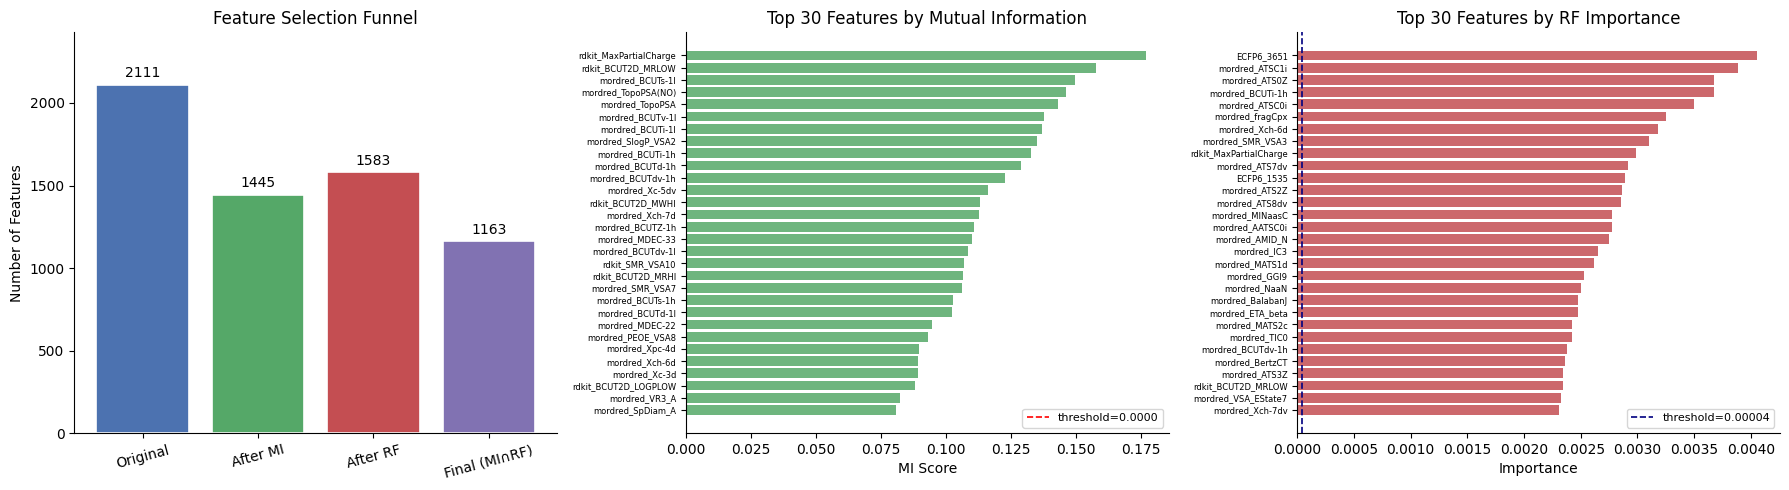

Figure saved → figures/feature_selection_summary.png


In [9]:
# ============================================================
# CELL 9: Visualisation — Feature Selection Summary
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Selection Funnel ---
ax = axes[0]
stages = ['Original', 'After MI', 'After RF', 'Final (MI∩RF)']
counts = [
    X_train.shape[1],
    len(mi_selected),
    len(rf_selected),
    len(final_features)
]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
bars = ax.bar(stages, counts, color=colors, edgecolor='white', linewidth=1.2)
ax.set_ylabel('Number of Features')
ax.set_title('Feature Selection Funnel')
ax.bar_label(bars, fmt='%d', padding=3, fontsize=10)
ax.set_ylim(0, max(counts) * 1.15)
ax.tick_params(axis='x', rotation=15)
sns.despine(ax=ax)

# --- Panel 2: Top-30 MI scores ---
ax = axes[1]
top_mi = mi_series.head(30)
ax.barh(range(len(top_mi)), top_mi.values[::-1], color='#55A868', alpha=0.85)
ax.set_yticks(range(len(top_mi)))
ax.set_yticklabels(top_mi.index[::-1], fontsize=6)
ax.axvline(mi_threshold, color='red', linestyle='--', linewidth=1.2, label=f'threshold={mi_threshold:.4f}')
ax.set_xlabel('MI Score')
ax.set_title('Top 30 Features by Mutual Information')
ax.legend(fontsize=8)
sns.despine(ax=ax)

# --- Panel 3: Top-30 RF importances ---
ax = axes[2]
top_rf = rf_series.head(30)
ax.barh(range(len(top_rf)), top_rf.values[::-1], color='#C44E52', alpha=0.85)
ax.set_yticks(range(len(top_rf)))
ax.set_yticklabels(top_rf.index[::-1], fontsize=6)
ax.axvline(rf_threshold, color='navy', linestyle='--', linewidth=1.2, label=f'threshold={rf_threshold:.5f}')
ax.set_xlabel('Importance')
ax.set_title('Top 30 Features by RF Importance')
ax.legend(fontsize=8)
sns.despine(ax=ax)

plt.tight_layout()
fig_path = PROJECT_ROOT / 'figures' / 'feature_selection_summary.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved → figures/feature_selection_summary.png")


In [10]:
# ============================================================
# CELL 10: QC-4 — Zero Data Leakage Verification
# ============================================================

print("=" * 55)
print("QC-4: Data Leakage Audit")
print("=" * 55)

# 1. Scaler fitted only on train
print(f"[OK] Scaler fitted on train set only ({X_train.shape[0]} samples)")

# 2. MI computed on train only
print(f"[OK] MI scores computed on train set only")

# 3. RF fitted on train only
print(f"[OK] RF importance computed on train set only")

# 4. Test set only transformed, never used in fitting
print(f"[OK] Test set transformed using pre-fitted scaler (no re-fit)")

# 5. Feature subset identical
assert list(X_train_selected.columns) == list(X_test_selected.columns)
print(f"[OK] Identical {len(final_features)} features in train and test")

# 6. Shape sanity check
assert X_train_selected.shape[0] == len(y_train)
assert X_test_selected.shape[0] == len(y_test)
print(f"[OK] Row counts match labels: train={len(y_train)}, test={len(y_test)}")

# 7. No NaN/Inf in final matrices
assert not X_train_selected.isnull().any().any(), "NaN found in X_train_selected!"
assert not X_test_selected.isnull().any().any(),  "NaN found in X_test_selected!"
assert not np.isinf(X_train_selected.values).any(), "Inf found in X_train_selected!"
assert not np.isinf(X_test_selected.values).any(),  "Inf found in X_test_selected!"
print(f"[OK] No NaN or Inf values in selected feature matrices")

print("=" * 55)
print(f"QC-4 PASSED — Feature selection complete")
print(f"  Original features  : {X_train.shape[1]}")
print(f"  Selected features  : {len(final_features)}")
print(f"  Retention          : {len(final_features)/X_train.shape[1]*100:.1f}%")
print(f"  X_train_selected   : {X_train_selected.shape}")
print(f"  X_test_selected    : {X_test_selected.shape}")
print("=" * 55)


QC-4: Data Leakage Audit
[OK] Scaler fitted on train set only (8627 samples)
[OK] MI scores computed on train set only
[OK] RF importance computed on train set only
[OK] Test set transformed using pre-fitted scaler (no re-fit)
[OK] Identical 1163 features in train and test
[OK] Row counts match labels: train=8627, test=4068
[OK] No NaN or Inf values in selected feature matrices
QC-4 PASSED — Feature selection complete
  Original features  : 2111
  Selected features  : 1163
  Retention          : 55.1%
  X_train_selected   : (8627, 1163)
  X_test_selected    : (4068, 1163)
